## T02 - Análisis de sensibilidad

#### Simulación de Procesos Financieros

José Armando Melchor Soto
 | 14/09/2026

---

### Libraries 

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from scipy.stats import norm

---

### Functions 

In [ ]:
def simulate_St(S0, r, sigma, T):
    """
    Simulates the underlying asset price at maturity using the Geometric Brownian Motion model.
    Parameters:
    S0 : float
        Initial price of the underlying asset.
    r : float
        Risk-free interest rate.
    sigma : float
        Volatility of the underlying asset.
    T : float
        Time to maturity in years.
    Returns:
    St : array-like
        Simulated underlying asset prices at maturity.
    """
    z = np.random.normal(0, 1, size=int(M))

    St = S0 * np.exp((r-1/2*sigma**2)*T + sigma*np.sqrt(T)*z)

    return St


def option_price_mc(payoff, r, T):
    """
    Calculates the option price using the Monte Carlo method.
    Parameters:
    payoff : array-like
        Simulated payoff of the option.
    r : float
        Risk-free interest rate.
    T : float
        Time to maturity in years.
    Returns:
    price : float
        Estimated option price using Monte Carlo simulation.
    """
    price = np.exp(-r*T) * np.mean(payoff)
    return price


def black_scholes(S0, K, r, sigma, T):
    """
    Calculates the Black-Scholes price for European call and put options.
    Parameters:
    S0 : float
        Initial price of the underlying asset.
    K : float
        Strike price of the option.
    r : float
        Risk-free interest rate.
    sigma : float
        Volatility of the underlying asset.
    T : float
        Time to maturity in years.
    Returns:
    call : float
        Price of the European call option.
    put : float
        Price of the European put option.
    """
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    call = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    put = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)

    return call, put


def payoff_put(St, K):
    """
    Calculates the payoff of a put option.
    Parameters:
    St : array-like
        Simulated underlying asset prices at maturity.
    K : float
        Strike price of the put option.
    Returns:
    payoff_put : array-like
        Payoff of the put option for each simulated underlying price.
    St : array-like
        Simulated underlying asset prices at maturity.
    """
    payoff_put = np.maximum(K - St, 0)

    return payoff_put, St


def payoff_call(St, K):
    """
    Calculates the payoff of a call option.
    Parameters:
    St : array-like
        Simulated underlying asset prices at maturity.
    K : float
        Strike price of the call option.
    Returns:
    payoff_call : array-like
        Payoff of the call option for each simulated underlying price.
    St : array-like
        Simulated underlying asset prices at maturity.
    """
    payoff_call = np.maximum(St - K, 0)

    return payoff_call, St


def payoff_plot(payoff_call, payoff_put, St):
    """
    Plots the payoff of call and put options against the underlying price.
    Parameters:
    payoff_call : array-like
        Payoff of the call option for each simulated underlying price.
    payoff_put : array-like
        Payoff of the put option for each simulated underlying price.
    St : array-like
        Simulated underlying asset prices at maturity.
    Returns:
    None
        Displays the payoff plot for call and put options.
    """
    idx = np.argsort(St)
    St_sorted = St[idx]
    call_sorted = payoff_call[idx]
    put_sorted = payoff_put[idx]

    plt.figure(figsize=(10, 6))
    plt.plot(St_sorted, call_sorted, label='Call Option Payoff')
    plt.plot(St_sorted, put_sorted, label='Put Option Payoff')
    plt.axhline(0, linewidth=1)
    plt.xlabel('Underlying Price ($S_T$)')
    plt.ylabel('Payoff')
    plt.title('Call and Put Option Payoffs')
    plt.legend()
    plt.grid()
    plt.show()
    
   
def parameter_table(parameter, values, S0, K, r, sigma, T):
    """
    Creates a table of call and put option prices while varying one parameter.
    Parameters:
    parameter : str
        Name of the parameter to vary.
    values : array-like
        Values used for the selected parameter.
    S0 : float
        Initial price of the underlying asset.
    K : float
        Strike price of the option.
    r : float
        Risk-free interest rate.
    sigma : float
        Volatility of the underlying asset.
    T : float
        Time to maturity in years.
    Returns:
    pandas.DataFrame
        Table containing the parameter values and corresponding call and put prices.
    """
    filas = []

    for value in values:
        params = {'S0': S0, 'K': K, 'r': r, 'sigma': sigma, 'T': T}
        params[parameter] = value

        call, put = black_scholes(params['S0'], params['K'], params['r'], params['sigma'], params['T'])

        filas.append({parameter: value, 'Call': call, 'Put': put})

    return pd.DataFrame(filas)


def plot_parameter(table, parameter):
    """
    Plots call and put option prices against a selected parameter.
    Parameters:
    table : pandas.DataFrame
        Table containing the parameter values and corresponding call and put prices.
    parameter : str
        Name of the parameter displayed on the x-axis.
    Returns:
    None
        Displays the option price plot.
    """
    plt.figure(figsize=(10, 6))
    plt.plot(table[parameter], table['Call'], marker='o', label='Call')
    plt.plot(table[parameter], table['Put'], marker='o', label='Put')
    plt.xlabel(parameter)
    plt.ylabel('Option Price')
    plt.title(f'Option Price vs {parameter}')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

---

### **Parte 1** 

#### Párametros 

In [3]:
S0 = 100 # Initial price 
K = 100 # Strike price
r = 0.05 # Risk-free rate
sigma = 0.2 # Volatility
T = 1 # Time to maturity in years
M = 100000 # Number of simulations

In [5]:
St = simulate_St(S0, r, sigma, T)

pay_off_call, St= payoff_call(St, K)
pay_off_put, St = payoff_put(St, K)

price_call_mc = option_price_mc(pay_off_call, r, T)
price_put_mc = option_price_mc(pay_off_put, r, T)

price_call_bs, price_put_bs = black_scholes(S0, K, r, sigma, T)


In [6]:
print("Call Monte Carlo:", price_call_mc)
print("Call Black-Scholes:", price_call_bs)
print("Put Monte Carlo:", price_put_mc)
print("Put Black-Scholes:", price_put_bs)

Call Monte Carlo: 10.422790224979861
Call Black-Scholes: 10.450583572185565
Put Monte Carlo: 5.585341352337843
Put Black-Scholes: 5.573526022256971


Los resultados de Monte Carlo son muy parecidos a los de Black-Scholes. Las diferencias se deben a la variación que existe cuando se hacen las simulaciones de Monte Carlo.


---

### **Parte 2 : Sensibilidad** 

#### Párametros 

In [ ]:
S0 = [80, 90, 100, 110, 120]
K = [80, 90, 100, 110, 120]
sigma = [0.1, 0.2, 0.3, 0.4, 0.5]
T = [0.25, 0.5, 1, 1.5, 2]
r = [0.05, 0.1, 0.15, 0.2]

S0_base = 100
K_base = 100
sigma_base = 0.2
T_base = 1
r_base = 0.05

In [ ]:
tabla_S0 = parameter_table('S0', S0, S0_base, K_base, r_base, sigma_base, T_base)
tabla_K = parameter_table('K', K, S0_base, K_base, r_base, sigma_base, T_base)
tabla_sigma = parameter_table('sigma', sigma, S0_base, K_base, r_base, sigma_base, T_base)
tabla_T = parameter_table('T', T, S0_base, K_base, r_base, sigma_base, T_base)
tabla_r = parameter_table('r', r, S0_base, K_base, r_base, sigma_base, T_base)

In [ ]:
tabla_S0

,S0,Call,Put
0,80,1.859420,16.982362
1,90,5.091222,10.214165
2,100,10.450584,5.573526
3,110,17.662954,2.785896
4,120,26.169044,1.291986


In [ ]:
tabla_K

,K,Call,Put
0,80,24.588835,0.687189
1,90,16.699448,2.310097
2,100,10.450584,5.573526
3,110,6.040088,10.675325
4,120,3.247477,17.395008


In [ ]:
tabla_sigma

,sigma,Call,Put
0,0.1,6.804958,1.927900
1,0.2,10.450584,5.573526
2,0.3,14.231255,9.354197
3,0.4,18.022951,13.145894
4,0.5,21.792604,16.915547


In [ ]:
tabla_T

,T,Call,Put
0,0.25,4.614997,3.372777
1,0.50,6.888729,4.419720
2,1.00,10.450584,5.573526
3,1.50,13.442905,6.217253
4,2.00,16.126780,6.610522


In [ ]:
tabla_r

,r,Call,Put
0,0.05,10.450584,5.573526
1,0.10,13.269677,3.753418
2,0.15,16.355968,2.426766
3,0.20,19.629887,1.502962


---

### **Parte 3** 

#### Visualización 

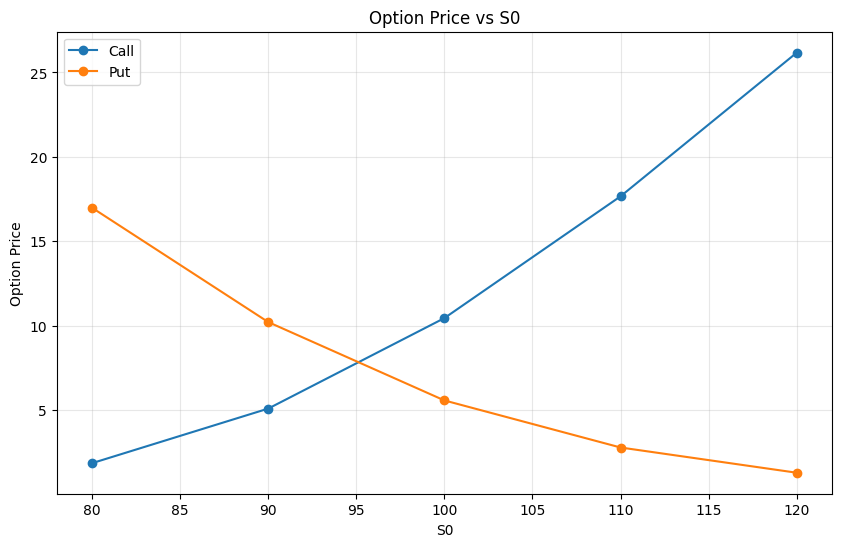

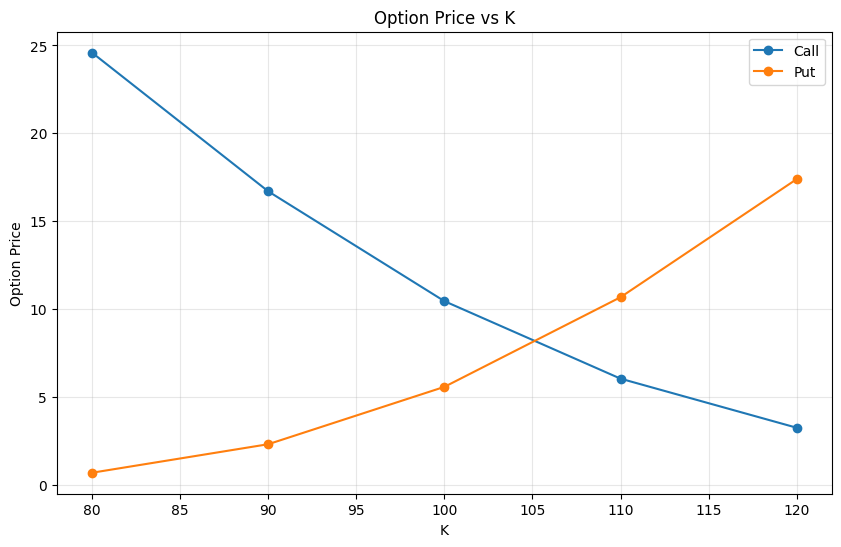

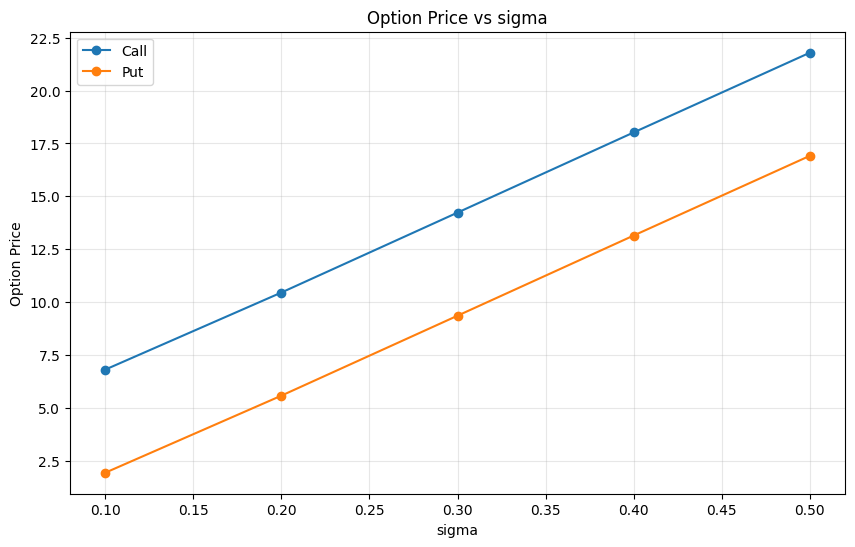

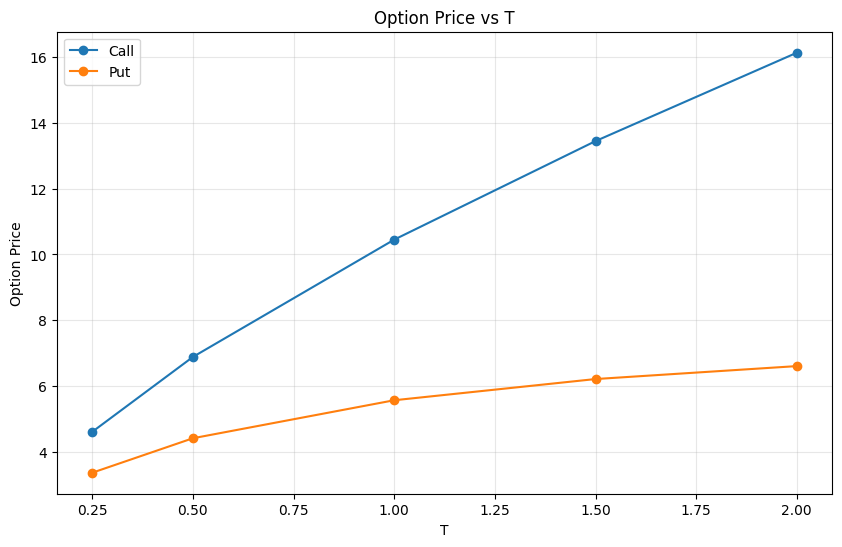

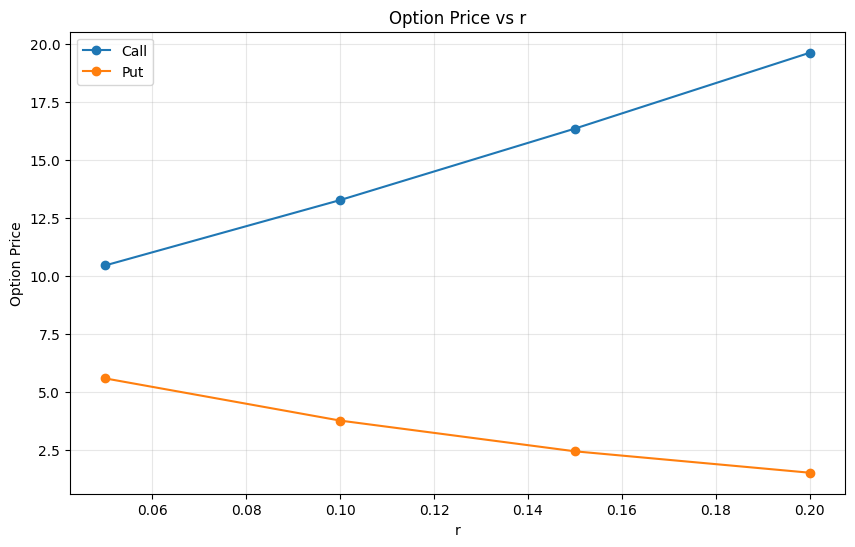

In [ ]:
plot_parameter(tabla_S0, 'S0')
plot_parameter(tabla_K, 'K')
plot_parameter(tabla_sigma, 'sigma')
plot_parameter(tabla_T, 'T')
plot_parameter(tabla_r, 'r')

---

### **Parte 4** 

#### a) Interpretación 

##### **Precio del activo**

- ¿Por qué una call aumenta cuando aumenta el precio de la acción?

Porque la call te permite comprar la acción a un precio fijo. Si el precio de la acción sube, puedes comprarla más barata que su precio de mercado, por lo que la opción vale más.

- ¿Por qué una put se comporta de manera distinta?

Porque una put te permite vender la acción a un precio fijo. Por eso, cuando el precio de la acción baja, la put se vuelve más valiosa.


##### **Volatilidad**

- ¿Por qué una mayor incertidumbre aumenta o disminuye el valor de la opción?

Una mayor volatilidad aumenta el valor de la opción, porque hay una mayor posibilidad de que el precio de la acción tenga un movimiento fuerte que beneficie al comprador.

##### **Tiempo**

- ¿Siempre es deseable tener más tiempo?

Para el comprador, casi siempre es así porque tiene más tiempo para que el precio de la acción se mueva a su favor.

- ¿Para quién resulta favorable?

Principalmente para el comprador de la opción, ya que tiene más oportunidades de obtener ganancias antes del vencimiento.


##### **Strike**

- ¿Cómo modifica el strike la probabilidad de termina in-the-money?

En una call, mientras menor sea el strike, es más fácil que la acción termine por encima de él. En una put, mientras mayor sea el strike, es más fácil que la acción termine por debajo de él.

- Definir in-the-money

Significa que la opción tiene valor al vencimiento. En una call, cuando el precio de la acción está por encima del strike; en una put, cuando está por debajo.

---

### **Parte 4** 

#### b)  Comparación con el mercado

Si fueras un inversionista, ¿cuál parámetro consideras más importante monitorear? ¿Por qué? Justifica usando tus resultados

Si fuera un inversionista, consideraría la volatilidad como el parámetro más importante a monitorear. En mis resultados se puede observar que cuando la volatilidad aumenta, tanto el precio de la call como el de la put aumentan considerablemente. Por ejemplo, al pasar de una volatilidad de 10% a 50%, la call aumenta de aproximadamente 6.8 a 21.8 y la put de 1.9 a 16.9. Esto muestra que la volatilidad puede tener un impacto importante en el precio de las opciones, incluso cuando los demás parámetros se mantienen constantes.
